# 🛒 EPOCH 5th Pilot Task Week3 (박정민)
> **주제: BMI 지수와 실제 비만 등급의 괴리 분석**
>> 부제: BMI 지표의 한계 극복을 위한 생활 습관 기반 비만 위험도 재정의


## Week1, 2 정리

### 컬럼 정보
- 수치형
> - Age : 나이
> - Height: 키
> - Weight: 몸무게
> - FCVC : 채소 섭취 빈도
> - NCP : 하루 섭취 끼니수
> - CH2O: 하루 섭취 물 양
> - FAF: 신체 활동 빈도
> - TUE : 전자기기 사용 빈도(휴대폰, 비디오게임, TV, 컴퓨터 등)

- 범주형
> - Gender: 성별
> - family_history_with_overweight: 과체중 가족력
> - FAVC : 고칼로리 음식 섭취 빈도
> - CAEC : 식사 사이 군것질 빈도
> - SMOKE : 흡연 여부
> - SCC: 섭취 칼로리 모니터링 여부
> - CALC : 알콜 섭취 빈도
> - MTRANS : 주로 사용하는 교통수단
> - NObeyesdad : 비만 수준

### 변수명 변경 + 결측치 및 중복 데이터 제거
    'Gender': 'gender',
    'Age': 'age',
    'Height': 'height',
    'Weight': 'weight',
    'family_history_with_overweight': 'family_history',
    'FAVC': 'high_cal_food',
    'FCVC': 'vegetable',
    'NCP': 'meal_count',
    'CAEC': 'snack',
    'SMOKE': 'smoke',
    'CH2O': 'water_intake',
    'SCC': 'cal_monitoring',
    'FAF': 'physical_activity',
    'TUE': 'tech_time',
    'CALC': 'alcohol_intake',
    'MTRANS': 'transport',
    'NObeyesdad': 'obesity_level'

### 이상치 확인
```
num_cols = ['age', 'height', 'weight', 'vegetable', 'meal_count', 'water_intake', 'physical_activity', 'tech_time']
cat_cols = ['gender', 'family_history', 'high_cal_food', 'snack',
            'smoke', 'cal_monitoring', 'alcohol_intake', 'transport', 'obesity_level'] ```

- 수치형 변수
  - 수치 데이터에 대한 이상치는 매우 정상으로 보인다.
- 범주형 변수
  - 각 변수의 unique값이 2 ~ 7개로 굉장히 합당하게 되어 있는 모습.
  ```
  - 이상치 문제가 없는 변수
    > gender, family_history, high_cal_food, obesity_level
  - 희소한 카테고리가 있는 변수
    > smoke(2.11%), cal_monitoring(4.6%), transport(2.64, 0.53, 0.34)
  - 매우 희소한 카테고리가 있는 변수
    > alcohol_intake(Always -> 1개, 0.05%)
    ```
  - 해당 사람은 하루 1끼, 칼로리 모니터링도 안하고, 가족력이 있으며, 운동도 많이 안하고, 간식도 많이 섭취하고, 알코올을 매일 마시지만, 주로 걷기를 하며 정상 비만 수준이다!!
  > 모든 데이터가 이상치가 있다고 보기 어려움, 이상치 제거를 하지 않은채로 모델링을 진행해보면 좋을 것 같다.

### 피쳐 엔지니어
- BMI 기반 파생 변수 생성
  - bmi_score: 몸무게(kg) / 키(m)^2  
  - bmi_label: WHO 표준 기준에 따른 BMI 등급  
  - actual_label_simplified: 비만 수준 단순화  
  - is_mismatch: BMI 등급과 실제 진단 등급이 다르면 1, 같으면 0

=> 전체 데이터 중 괴리가 발생하는 샘플 수: 25개  
=> 괴리율: 1.20%

- 나이관련 파생 변수 생성
  - age_group: 10, 20, 30, 40, 50대 그룹 변수
- 상관관계 파생 변수 생성
  - high_cal_num: 고칼로리
  - snack_num: 간식
  - alc_num: 알코올
  - habit_risk_score: 안 좋은 습관(s_high_cal, s_snack, s_alc) - 좋은 습관(s_veg, s_exercise, s_water)
  - age_buffer_index: 나이 가중치

## Task. 모델링 및 평가
- 모델 유형 정의
- 모델 학습 과정
- 모델 평가 지표
- 모델 해석
- Feature importance
- 시각화

#### 라이브러리 호출 및 데이터셋 확인

In [1]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
pd.set_option('display.max_columns', None)

In [60]:
df_enc = pd.read_csv('/content/df_Encoding.csv') # 데이터셋 호출
df_enc.head()

,age,gender,height,weight,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,bmi_score,is_mismatch,high_cal_num,snack_num,alc_num,habit_risk_score,age_buffer_index,transport_Bike,transport_Motorbike,transport_Public_Transportation,transport_Walking,obesity_target
0,21.0,0,1.62,64.0,0,2.0,3.0,0,0,2.0,1,0.0,1.0,24.386526,0,0,1,0,-0.666667,-0.031745,False,False,True,False,1
1,21.0,0,1.52,56.0,0,3.0,3.0,1,1,3.0,1,3.0,0.0,24.238227,0,0,1,1,-2.333333,-0.111106,False,False,True,False,1
2,23.0,1,1.80,77.0,0,2.0,3.0,0,0,2.0,1,2.0,1.0,23.765432,0,0,1,2,-0.666667,-0.028984,False,False,True,False,1
3,27.0,1,1.80,87.0,0,3.0,3.0,0,0,2.0,0,2.0,0.0,26.851852,0,0,1,2,-1.166667,-0.043208,False,False,False,True,2
4,22.0,1,1.78,89.8,0,2.0,1.0,0,0,2.0,0,0.0,0.0,28.342381,0,0,1,1,-0.333333,-0.015151,False,False,True,False,3


In [61]:
df_enc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2087 entries, 0 to 2086
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              2087 non-null   float64
 1   gender                           2087 non-null   int64  
 2   height                           2087 non-null   float64
 3   weight                           2087 non-null   float64
 4   high_cal_food                    2087 non-null   int64  
 5   vegetable                        2087 non-null   float64
 6   meal_count                       2087 non-null   float64
 7   cal_monitoring                   2087 non-null   int64  
 8   smoke                            2087 non-null   int64  
 9   water_intake                     2087 non-null   float64
 10  family_history                   2087 non-null   int64  
 11  physical_activity                2087 non-null   float64
 12  tech_time           

In [62]:
df_enc.describe(include='all')

,age,gender,height,weight,high_cal_food,vegetable,meal_count,cal_monitoring,smoke,water_intake,family_history,physical_activity,tech_time,bmi_score,is_mismatch,high_cal_num,snack_num,alc_num,habit_risk_score,age_buffer_index,transport_Bike,transport_Motorbike,transport_Public_Transportation,transport_Walking,obesity_target
count,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2087.000000,2063.000000,2063.000000,2087,2087,2087,2087,2087.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,True,False,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2080,2076,1558,2032,NaN
mean,24.353090,0.504073,1.702674,86.858730,0.883565,2.421466,2.701179,0.045999,0.021083,2.004749,0.825108,1.012812,0.663035,29.765758,0.011979,0.883565,1.146143,0.729756,-0.039627,-0.001439,NaN,NaN,NaN,NaN,3.132247
std,6.368801,0.500103,0.093186,26.190847,0.320823,0.534737,0.764614,0.209533,0.143695,0.608284,0.379966,0.853475,0.608153,8.024934,0.108817,0.320823,0.459494,0.517008,0.678787,0.031097,NaN,NaN,NaN,NaN,1.985747
min,14.000000,0.000000,1.450000,39.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,12.998685,0.000000,0.000000,0.000000,0.000000,-2.666667,-0.140343,NaN,NaN,NaN,NaN,0.000000
25%,19.915937,0.000000,1.630178,66.000000,1.000000,2.000000,2.697467,0.000000,0.000000,1.590922,1.000000,0.124505,0.000000,24.368897,0.000000,1.000000,1.000000,0.000000,-0.467232,-0.018685,NaN,NaN,NaN,NaN,1.000000
50%,22.847618,1.000000,1.701584,83.101100,1.000000,2.396265,3.000000,0.000000,0.000000,2.000000,1.000000,1.000000,0.630866,28.896224,0.000000,1.000000,1.000000,1.000000,-0.030044,-0.001256,NaN,NaN,NaN,NaN,3.000000
75%,26.000000,1.000000,1.769491,108.015907,1.000000,3.000000,3.000000,0.000000,0.000000,2.466193,1.000000,1.678102,1.000000,36.095538,0.000000,1.000000,1.000000,1.000000,0.386684,0.016394,NaN,NaN,NaN,NaN,5.000000


#### 데이터셋 수정

In [63]:
# 다시 is_mismatch 변경 -> WHO에서 정한 4개의 기준보다 현재 데이터셋에 맞게 7개로 분할
def get_bmi_target_7(bmi):
    if bmi < 18.5: return 0    # Insufficient
    elif bmi < 25: return 1    # Normal
    elif bmi < 27.5: return 2  # Overweight I
    elif bmi < 30: return 3    # Overweight II
    elif bmi < 35: return 4    # Obesity I
    elif bmi < 40: return 5    # Obesity II
    else: return 6             # Obesity III

# get_bmi_target 함수를 이용한 bmi 기준 적용
df_enc['bmi_predicted_target'] = df_enc['bmi_score'].apply(get_bmi_target_7)

# 괴리 여부 확인
df_enc['is_mismatch'] = (df_enc['bmi_predicted_target'] != df_enc['obesity_target']).astype(int)

print(f"7단계 기준 괴리 샘플 수: {df_enc['is_mismatch'].sum()}개")

7단계 기준 괴리 샘플 수: 170개


In [64]:
df_enc_fix = df_enc.copy()

#### RandomForest
- 랜덤으로 섞어서 train과 test를 나누고, 해당 RandomForest 모델을 활용하여 진행.


In [51]:
df_enc.columns # 컬럼 피쳐 확인

Index(['age', 'gender', 'height', 'weight', 'high_cal_food', 'vegetable',
       'meal_count', 'cal_monitoring', 'smoke', 'water_intake',
       'family_history', 'physical_activity', 'tech_time', 'bmi_score',
       'is_mismatch', 'high_cal_num', 'snack_num', 'alc_num',
       'habit_risk_score', 'age_buffer_index', 'transport_Bike',
       'transport_Motorbike', 'transport_Public_Transportation',
       'transport_Walking', 'obesity_target', 'bmi_predicted_target'],
      dtype='object')

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = df_enc.drop(columns=['obesity_target', 'is_mismatch', 'bmi_predicted_target'])  # 독립 변수
y = df_enc['obesity_target'] # 타겟 변수

# 데이터 분할 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 모델 생성 및 학습
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 성능 확인
y_pred = model.predict(X_test)
print(f"전체 테스트셋 정확도: {accuracy_score(y_test, y_pred):.4f}")

전체 테스트셋 정확도: 0.9880


- 모델의 괴리가 총 170개, 약 8퍼이기에 정확도가 높을 수 밖에 없다.

In [53]:
# 전체 데이터에 대해 모델의 예측값 생성
df_enc['model_predicted_target'] = model.predict(X)

# 괴리 데이터만 추출
mismatch_group = df_enc[df_enc['is_mismatch'] == 1]

# 그 170명 중 모델이 실제 등급을 정확히 맞힌 비율 계산
model_correct_count = (mismatch_group['model_predicted_target'] == mismatch_group['obesity_target']).sum()
model_recovery_rate = model_correct_count / len(mismatch_group)

print(f"--- BMI 오진 그룹(170명)에 대한 모델의 예측 및 복구 성능 ---")
print(f"모델의 정답을 맞힌 수: {model_correct_count}명")
print(f"모델의 정답 복구율: {model_recovery_rate:.2%}")

--- BMI 오진 그룹(170명)에 대한 모델의 예측 및 복구 성능 ---
모델의 정답을 맞힌 수: 168명
모델의 정답 복구율: 98.82%


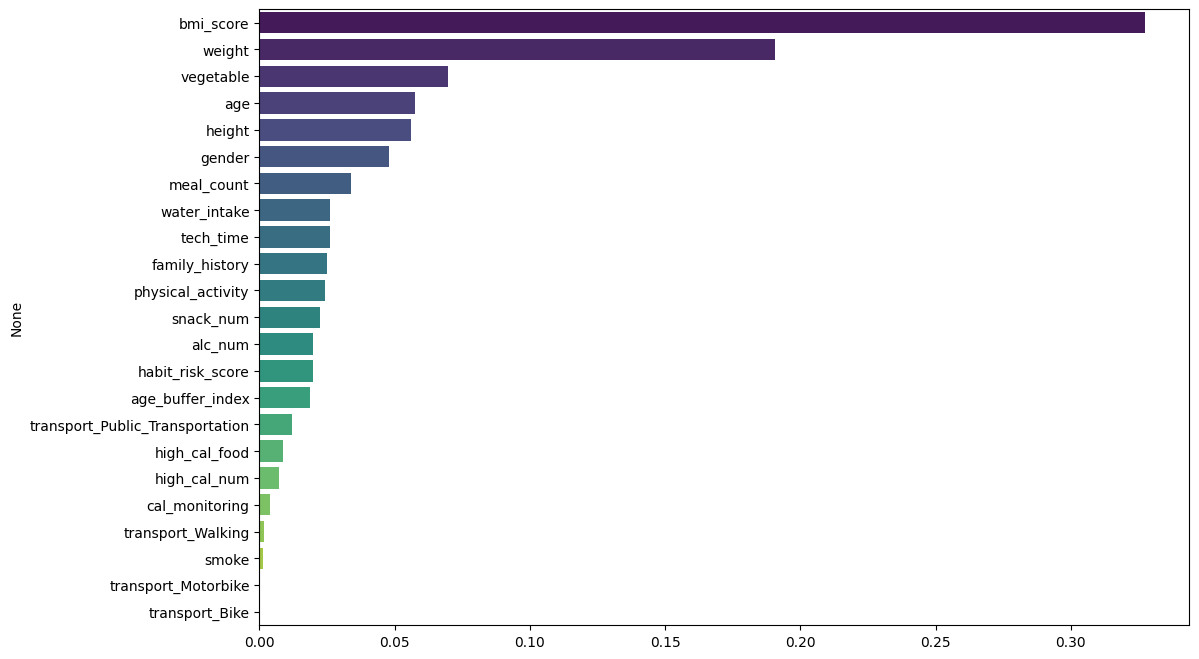

In [54]:
# 변수 중요도 추출
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

# 시각화
plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=features[indices], palette='viridis')
plt.show()

- 본 목적에 부합하지 않게, 단순 bmi의 점수가 해당 모델의 예측력과 설명력을 높이고 있다.
- 따라서 bmi로 약 8퍼의 괴리율이 나왔으나, 단순 train, test에서 모델로 학습을 진행하면 168/170으로 오분류를 많이 줄일 수 있다.

#### bmi관련 피쳐 제거 후 습관 데이터로 예측하는 모델 생성(RF)
- bmi와 관련된 키나 몸무게를 제외하고 다른 피쳐들로 비만 수준을 예측해보자.
- train은 is_mismatch가 맞는 데이터, test는 괴리 데이터

In [65]:
# 몸무게, 키, BMI 점수까지 싹 다 제거 (오직 습관만 남기기)
df_enc1 = df_enc_fix.copy()

df_match = df_enc1[df_enc1['is_mismatch'] == 0]  # 괴리가 아닌 데이터셋
df_mismatch = df_enc1[df_enc1['is_mismatch'] == 1]  # 괴리인 데이터셋

# 타겟 변수와 BMI관련 피쳐 제거
drop_cols_hard = ['obesity_target', 'is_mismatch', 'bmi_predicted_target',
                  'weight', 'height', 'bmi_score']

# X와 Y 분리
X_train_hard = df_match.drop(columns=drop_cols_hard)
y_train_hard = df_match['obesity_target']

X_test_hard = df_mismatch.drop(columns=drop_cols_hard)
y_test_hard = df_mismatch['obesity_target']

# 모델 학습
rf_hard = RandomForestClassifier(n_estimators=100, random_state=42)
rf_hard.fit(X_train_hard, y_train_hard)

# 습관만으로 BMI 오진 복구력 테스트
y_pred_hard = rf_hard.predict(X_test_hard)
acc_hard = accuracy_score(y_test_hard, y_pred_hard)

print(f"[습관 전용 모델] BMI 오진 복구율: {acc_hard:.2%}")
print(f"구제 성공: {(y_pred_hard == y_test_hard).sum()}명 / 170명")

[습관 전용 모델] BMI 오진 복구율: 80.00%
구제 성공: 136명 / 170명


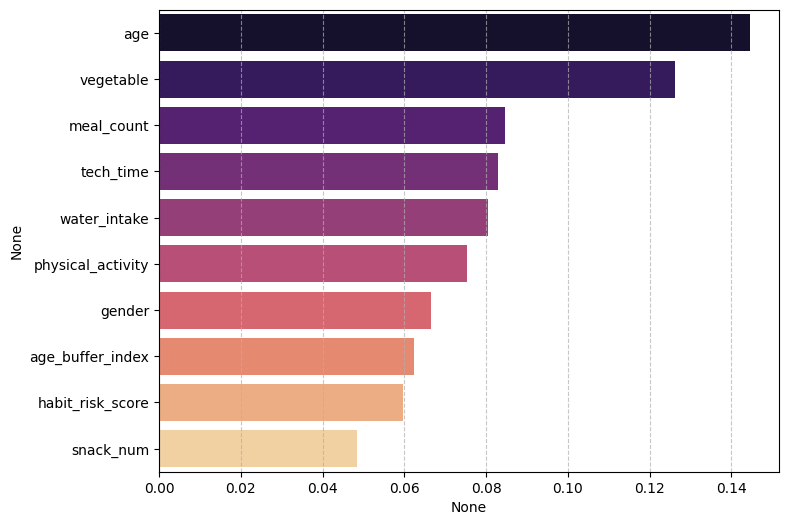

--- Top 10 Feature Importance ---
age                  0.144479
vegetable            0.126156
meal_count           0.084645
tech_time            0.082834
water_intake         0.080533
physical_activity    0.075217
gender               0.066599
age_buffer_index     0.062398
habit_risk_score     0.059663
snack_num            0.048508
dtype: float64


In [66]:
# 피쳐 중요도 계산
fi_hard = pd.Series(rf_hard.feature_importances_, index=X_train_hard.columns).sort_values(ascending=False)

# 시각화
plt.figure(figsize=(8, 6))
sns.barplot(x=fi_hard.head(10), y=fi_hard.head(10).index, palette='magma')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("--- Top 10 Feature Importance ---")
print(fi_hard.head(10))

In [81]:
df_mismatch[['obesity_target', 'bmi_predicted_target']]

,obesity_target,bmi_predicted_target
11,3,2
16,3,2
31,3,2
89,3,2
119,3,2
...,...,...
2018,6,5
2020,6,5
2044,6,5
2072,6,5


In [78]:
df_mismatch['obesity_target'].value_counts().sort_index()

,count
obesity_target,
0,4
1,3
2,18
3,66
4,5
5,18
6,56


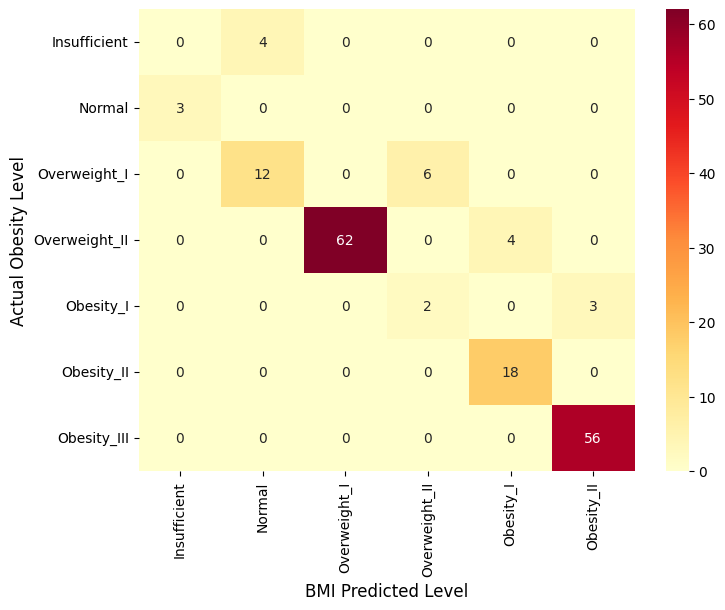

--- 170명 괴리 분석 결과 ---
1. BMI가 실제보다 낮게 평가 (위험 간과): 153명
2. BMI가 실제보다 높게 평가 (과잉 진단): 17명


In [84]:
# 비만 수준 라벨링 (숫자를 문자로)
label_map = {
    0: 'Insufficient', 1: 'Normal', 2: 'Overweight_I',
    3: 'Overweight_II', 4: 'Obesity_I', 5: 'Obesity_II', 6: 'Obesity_III'
}

error_matrix = pd.crosstab(
    df_mismatch['obesity_target'],
    df_mismatch['bmi_predicted_target'],
    dropna=False
)

# 인덱스와 컬럼을 이름으로 변경
error_matrix.index = [label_map[i] for i in error_matrix.index]
error_matrix.columns = [label_map[i] for i in error_matrix.columns]

# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(error_matrix, annot=True, fmt='d', cmap='YlOrRd', cbar=True)
plt.xlabel('BMI Predicted Level', fontsize=12)
plt.ylabel('Actual Obesity Level', fontsize=12)
plt.show()

# 방향성 확인
under_est = df_mismatch[df_mismatch['obesity_target'] > df_mismatch['bmi_predicted_target']]
over_est = df_mismatch[df_mismatch['obesity_target'] < df_mismatch['bmi_predicted_target']]

print(f"--- 170명 괴리 분석 결과 ---")
print(f"1. BMI가 실제보다 낮게 평가 (위험 간과): {len(under_est)}명")
print(f"2. BMI가 실제보다 높게 평가 (과잉 진단): {len(over_est)}명")

- BMI로만 비만 수준을 판단할 경우 170명 중 약 90%인 153명을 실제보다 안전하다고 오진했음을 알 수 있다.

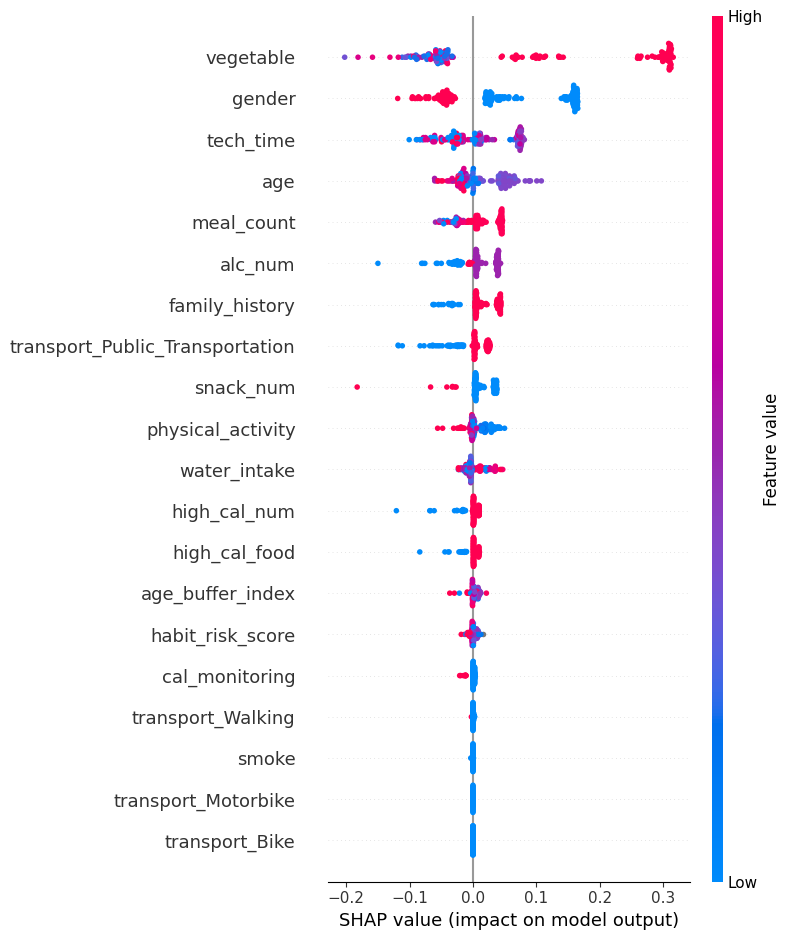

In [74]:
# SHAP 진행
import shap

# SHAP 계산
explainer = shap.TreeExplainer(rf_hard)
shap_values = explainer.shap_values(X_test_hard)

if isinstance(shap_values, list):
    target_shap = shap_values[6]
else:
    target_shap = shap_values[:, :, 6] if len(shap_values.shape) == 3 else shap_values

# 시각화
plt.figure(figsize=(8, 6))
shap.summary_plot(target_shap, X_test_hard)

- 비만3 그룹에 대한 SHAP 해석
  - 채소: 채소를 많이 먹는데도 비만 위험이 높음
    > 비만도가 높은 그룹은 절대적인 식사량 자체가 많아 채소 섭취량도 동반 상승한 패턴이라 예상
  - 나이: 나이가 적은 사람이 비만이 높음
    > 나이가 어려서 겉보기엔 정상이지만, 사실 몸 안은 이미 비만인 사람들
  - 식사 횟수: 식사 횟수가 많은 사람이 비만 등급을 높임
    > 단순히 많이 먹으면 살도 찜
  - 성별: 여성(0)인 그룹이 비만 위험이 높음
    > BMI는 여성의 낮은 근육량과 높은 지방 비중을 제대로 반영하지 못해 '정상'이라 오진했지만, 해당 모델은 성별 특성을 고려해 실제로는 '비만'임을 알아냄

## 정리

- [모델 1] BMI점수 결합 모델
  - 주요 피처: bmi_score, weight, vegetable 등
  - 괴리 데이터셋 복구율: 98.2% (168/170)
  - 분석 목적: BMI 수치가 놓친 미세한 등급 차이를 RandomForest가 얼마나 정확히 보정할 수 있는가
  - 핵심 결론: BMI는 비만 예측의 강력한 지표이나, 약 8%의 사각지대가 존재하기에, 다른 피쳐와 결함하여 비만 수준을 정하는 것이 더욱 정확해짐

- [모델 2] 습관 전용 모델
  - 주요 피처: age, vegetable, meal_count
  - 괴리 데이터셋 복구율: 80% (136/170)
  - 분석 목적: 키, 몸무게 없이 오직 생활 습관을 피쳐로 한 모델이 BMI의 오진을 잡아낼 수 있는가
  - 핵심 결론: 괴리 10명 중 8명은 나이와 식습관만으로도 실제 건강 상태를 찾아낼 수 있음.

1. 데이터셋 및 분석 목적 설명
> BMI 공식의 한계를 지적하고, 7단계 세분화를 통해 'BMI 사각지대(170명)'를 정의

2. 모델 학습 코드 작성 및 Train/Test Split
> 일반적인 8:2 분할 + 'Match 그룹(학습) vs Mismatch 그룹(테스트)'이라는 분할 방식을 적용

3. 모델 평가 지표 계산
> 단순 Accuracy(98.8%) 외에도, 우리가 정의한 '복구율(Recovery Rate, 80~95%)' 지표 계산

4. 모델 비교 및 해석
> 비교: 'BMI 포함 모델' vs '습관 전용 모델'의 성능 및 변수 영향력 대조  